# Spoiler Detection on IMDB movie reviews

## Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


## IMDB Spoiler Dataset

source: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset

### Importing and Inspecting Raw Data

In [3]:
from pathlib import Path


In [4]:
ROOT = Path.cwd().resolve().parent
DATA_DIR = ROOT / 'data'
REVIEW_PATH = DATA_DIR / 'IMDB_reviews.json'
MOVIE_PATH = DATA_DIR / 'IMDB_movie_details.json'
CSV_PATH = DATA_DIR / 'preprocessed_reviews.csv'

# raw text
if CSV_PATH.exists():
    review_data = pd.read_csv(CSV_PATH, encoding='utf-8')
else:
    review_data = pd.read_json(REVIEW_PATH, lines=True)
review_data.head(3)


,review_date,movie_id,user_id,is_spoiler,review_text,rating,review_summary,word_count,cleaned_text,processed_text,final_text
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,843,in its oscar year shawshank redemption written...,in it oscar year shawshank redemption write an...,oscar year shawshank redemption write direct f...
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,223,the shawshank redemption is without a doubt on...,the shawshank redemption be without a doubt on...,shawshank redemption without doubt one brillia...
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,250,i believe that this film is the best story eve...,i believe that this film be the best story eve...,believe film best story ever tell film im tell...


In [5]:
movie_data = pd.read_json(MOVIE_PATH, lines=True)
movie_data.head(3)


,movie_id,plot_summary,duration,genre,rating,release_date,plot_synopsis
0,tt0105112,"Former CIA analyst, Jack Ryan is in England wi...",1h 57min,"[Action, Thriller]",6.9,1992-06-05,"Jack Ryan (Ford) is on a ""working vacation"" in..."
1,tt1204975,"Billy (Michael Douglas), Paddy (Robert De Niro...",1h 45min,[Comedy],6.6,2013-11-01,Four boys around the age of 10 are friends in ...
2,tt0243655,"The setting is Camp Firewood, the year 1981. I...",1h 37min,"[Comedy, Romance]",6.7,2002-04-11,


In [6]:
# see the sample of spoiler reviews & non-spoiler reviews
review_data['word_count']=review_data['review_text'].apply(lambda x:len(x.split()))

spoiler_samples = review_data[(review_data['is_spoiler'] == 1) & (review_data['word_count'] < 70)].head(2)
non_spoiler_samples = review_data[(review_data['is_spoiler'] == 0) & (review_data['word_count'] < 70)].head(2)

samples = pd.concat([spoiler_samples, non_spoiler_samples])

with pd.option_context('display.max_colwidth', None):
    display(samples[['review_text', 'is_spoiler', 'word_count']])


,review_text,is_spoiler,word_count
75,"This movie will be one of my favorite's of all time, it's heartwarming, sad, funny at times and won't let you down. justice is served! Morgan Freeman plays the supporting character for Tim Robbins and just made the movie. He creates so much emotion to this film as the narrator and supporting character to the storyline it just leaves you in total awe of his talent.",True,66
78,"Excellent movie, I have watched it twice no thrice :) very thrilling :). The characters fulfilled their roles very good. The graphics was astonishing in my eyes. If you want to enjoy these movie watch this in HD format. It was very memorable to watch such kind of movie. The shawshank redemption is included in my top ten favorite to watch. I will give it an excellent score.",True,68
993,"This is definitely one of my favorite movies -- it makes me cry and laugh and ache inside all at once. Tim Robbins, you make my days a little brighter -- thank you!",False,33
1003,Shawshank Redemption is without a doubt the most uplifting and touching film I have ever seen. It is the only movie I've seen that has made tears of happiness come to my eyes. I would (and do) recommend this film to anyone and everyone.,False,44


### Data Exploration (EDA)

In [7]:
review_data.shape, movie_data.shape


((573913, 11), (1572, 7))

is_spoiler
False    422989
True     150924
Name: count, dtype: int64


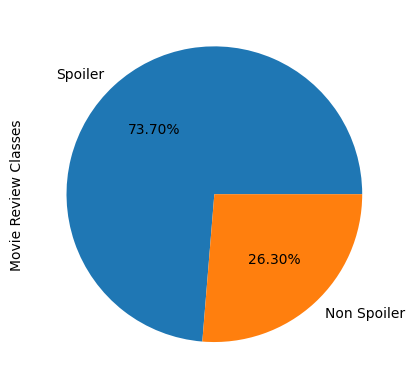

In [8]:
counts = review_data['is_spoiler'].value_counts()
print(counts)

plt.pie(counts, labels=['Spoiler','Non Spoiler'],autopct='%.2f%%')
plt.ylabel('Movie Review Classes');


<Axes: xlabel='word_count', ylabel='Count'>

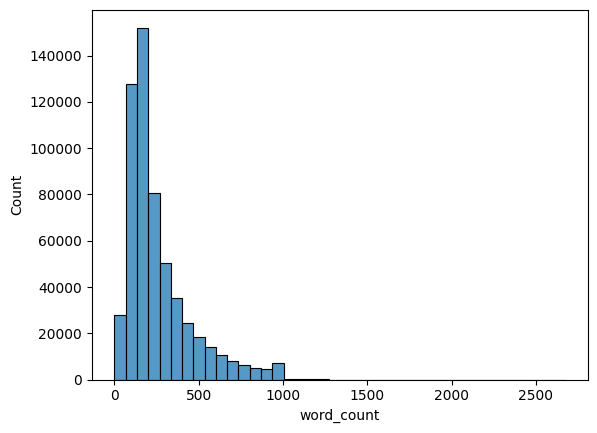

In [9]:
# How many words per review
sns.histplot(x=review_data['word_count'], bins=40)


### Distribution of spoiler and non-spoiler reviews based on word count

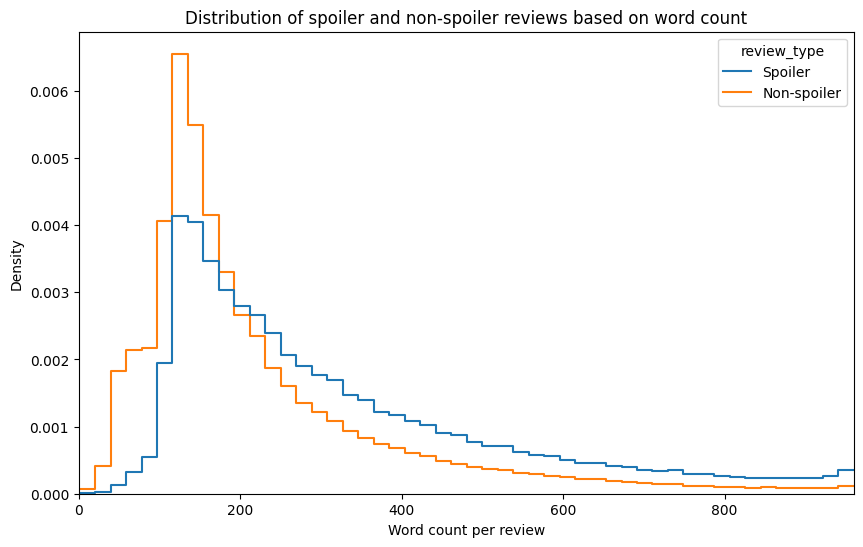

In [10]:
# Distribution of spoiler and non-spoiler reviews based on word count
word_count_cutoff = review_data['word_count'].quantile(0.99)
word_count_plot = review_data.loc[
    review_data['word_count'] <= word_count_cutoff,
    ['word_count', 'is_spoiler']
].copy()
word_count_plot['review_type'] = word_count_plot['is_spoiler'].map({True: 'Spoiler', False: 'Non-spoiler'})

plt.figure(figsize=(10, 6))
sns.histplot(
    data=word_count_plot,
    x='word_count',
    hue='review_type',
    bins=50,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
)
plt.title('Distribution of spoiler and non-spoiler reviews based on word count')
plt.xlabel('Word count per review')
plt.ylabel('Density')
plt.xlim(0, word_count_cutoff)
plt.show()


## Data Preprocessing NLTK


### Standardising data to lower case & punctuation removal

In [11]:
# Standardising data to lower case & punctuation removal
import re

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Apply cleaning to the text column
review_data['cleaned_text'] = review_data['review_text'].apply(clean_text)


In [12]:
# sample review
review_data['cleaned_text'].iloc[2]


'i believe that this film is the best story ever told on film and im about to tell you whytim robbins plays andy dufresne a city banker wrongfully convicted of murdering his wife and her lover he is sent to shawshank prison in 1947 and receives a double life sentence for the crime andy forms an unlikely friendship with red morgan freeman the man who knows how to get things andy faces many trials in prison but forms an alliance with the wardens because he is able to use his banking experience to help the corrupt officials amass personal fortunes the story unfoldsi was so impressed with how every single subplot was given a great deal of respect and attention from the director the acting was worldclass i have never seen tim robbins act as well since morgan freeman maybe eg seven the twists were unexpected an although this film had a familiar feel it wasnt even slightly pretentious or cliched it was original the cinematography was grand and expressive it gave a real impression of the sheer

### Tokinaizing & Lemmatizing data

In [13]:
# Tokinaizing & Lemmatizing data
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data files
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\12467\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\12467\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\12467\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\12467\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\12467\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\12467\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_percep

In [14]:
from nltk import pos_tag
from nltk.corpus import wordnet

# Function to get the wordnet POS tag
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


In [15]:
def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    lemmatized_tokens = [lemmatizer.lemmatize(token, get_wordnet_pos(pos)) for token, pos in pos_tags]
    return ' '.join(lemmatized_tokens)

# Apply tokenization and lemmatization
if not CSV_PATH.exists():
    review_data['processed_text'] = review_data['cleaned_text'].apply(tokenize_and_lemmatize)


In [16]:
# Display the first few rows of the processed data
review_data[['review_text', 'processed_text']].head()


,review_text,processed_text
0,"In its Oscar year, Shawshank Redemption (writt...",in it oscar year shawshank redemption write an...
1,The Shawshank Redemption is without a doubt on...,the shawshank redemption be without a doubt on...
2,I believe that this film is the best story eve...,i believe that this film be the best story eve...
3,"**Yes, there are SPOILERS here**This film has ...",yes there be spoiler herethis film have have s...
4,At the heart of this extraordinary movie is a ...,at the heart of this extraordinary movie be a ...


### Dealing with stop words

In [17]:
# Dealing with stop words
from nltk.corpus import stopwords

# Download stopwords list
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\12467\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
# Dealing with stop words
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return ' '.join(filtered_tokens)

# Remove stop words
if not CSV_PATH.exists():
    review_data['final_text'] = review_data['processed_text'].apply(remove_stopwords)


In [19]:
# Display the first few rows of the final processed data
review_data[['review_text', 'final_text']].head()


,review_text,final_text
0,"In its Oscar year, Shawshank Redemption (writt...",oscar year shawshank redemption write direct f...
1,The Shawshank Redemption is without a doubt on...,shawshank redemption without doubt one brillia...
2,I believe that this film is the best story eve...,believe film best story ever tell film im tell...
3,"**Yes, there are SPOILERS here**This film has ...",yes spoiler herethis film emotional impact fin...
4,At the heart of this extraordinary movie is a ...,heart extraordinary movie brilliant indelible ...


In [20]:
# Save preprocessed data
if not CSV_PATH.exists():
    review_data.to_csv(CSV_PATH , index=False, encoding='utf-8')


## Train-test split

We split the raw reviews by `movie_id` before fitting TF-IDF.
This avoids leaking vocabulary and inverse-document-frequency weights from validation or test reviews into training, and it also keeps reviews from the same film in the same partition.


In [21]:
from sklearn.model_selection import GroupShuffleSplit

y = review_data['is_spoiler']
groups = review_data['movie_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss.split(review_data, y, groups))

train_val_df = review_data.iloc[train_val_idx].reset_index(drop=True)
test_df = review_data.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_idx, val_idx = next(
    gss2.split(train_val_df, train_val_df['is_spoiler'], train_val_df['movie_id'])
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

y_train = train_df['is_spoiler']
y_val = val_df['is_spoiler']
y_test = test_df['is_spoiler']
train_groups = train_df['movie_id']

train_df.shape, val_df.shape, test_df.shape


((412358, 11), (82825, 11), (78730, 11))

## Feature Extraction

### TF-IDF

TF-IDF is fit on the training reviews only, then applied to validation and test splits.


In [22]:
# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit the vectorizer on the training split only to avoid data leakage.
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_df['final_text'])
X_val = vectorizer.transform(val_df['final_text'])
X_test = vectorizer.transform(test_df['final_text'])

X_train.shape, X_val.shape, X_test.shape


((412358, 5000), (82825, 5000), (78730, 5000))

## Models Development

We now train and compare Logistic Regression and Naive Bayes on the movie-level split.
Hyperparameter tuning uses grouped cross-validation on the training set, so reviews from the same film do not appear in different folds.
The validation set is used for model-selection checks, and the test set is kept for the final report.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, GroupKFold, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score


### Hyperparameter search with grouped cross-validation

#### 1) Logistic Regression


In [24]:
# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# Initialize grouped cross-validation and the model.
group_cv = GroupKFold(n_splits=5)
LR = LogisticRegression(max_iter=1000)

# Perform grid search without mixing reviews from the same movie across folds.
grid_search = GridSearchCV(LR, param_grid, cv=group_cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train, groups=train_groups)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

best_lr = grid_search.best_estimator_

y_val_pred_best = best_lr.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best))

y_pred_best_lr = best_lr.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))


Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best Cross-validation Score: 0.7673405262237286
Validation Accuracy: 0.7778810745547842
Test Accuracy: 0.7808332274863458


### Lexical cue analysis

The feature-weight interpretation is moved to the `Failure / Limitation` section below so it can be discussed together with the model's false negatives and weak spoiler recall.

#### 2) MultinomialNB (Naive Bayes)


In [25]:
# Define the parameter grid
param_grid_nb = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

NB = MultinomialNB()

grid_search_nb = GridSearchCV(NB, param_grid_nb, cv=group_cv, scoring='accuracy', n_jobs=-1)
grid_search_nb.fit(X_train, y_train, groups=train_groups)

print("Best Parameters:", grid_search_nb.best_params_)
print("Best Cross-validation Score:", grid_search_nb.best_score_)

best_nb = grid_search_nb.best_estimator_

y_val_pred_best_nb = best_nb.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best_nb))

y_pred_best_nb = best_nb.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_nb))


Best Parameters: {'alpha': 0.1}
Best Cross-validation Score: 0.7420348668287048
Validation Accuracy: 0.7538545125264111
Test Accuracy: 0.7570303569160421


## Performance comparison


In [26]:
# Logistic Regression
print("Logistic Regression:")
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred_best))
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print("Test Classification Report:\n", classification_report(y_test, y_pred_best_lr))
print("-------------------------------------------------------------")

# Naive Bayes
print("Naive Bayes:")
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best_nb))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred_best_nb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_nb))
print("Test Classification Report:\n", classification_report(y_test, y_pred_best_nb))


Logistic Regression:
Validation Accuracy: 0.7778810745547842
Validation Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.94      0.86     61833
        True       0.63      0.30      0.40     20992

    accuracy                           0.78     82825
   macro avg       0.71      0.62      0.63     82825
weighted avg       0.76      0.78      0.75     82825

Test Accuracy: 0.7808332274863458
Test Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.94      0.87     59065
        True       0.63      0.29      0.40     19665

    accuracy                           0.78     78730
   macro avg       0.72      0.62      0.63     78730
weighted avg       0.76      0.78      0.75     78730

-------------------------------------------------------------
Naive Bayes:
Validation Accuracy: 0.7538545125264111
Validation Classification Report:
               precision    recall  f1

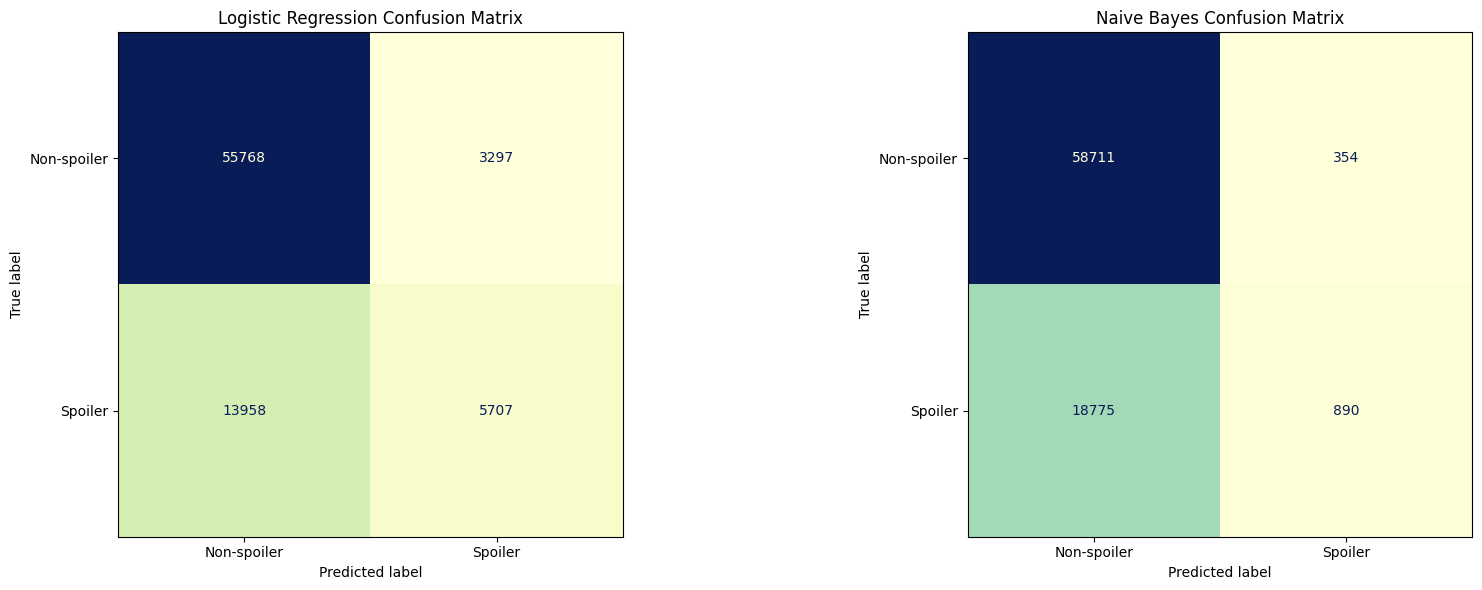

In [27]:
# Confusion matrix comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

cm_lr = confusion_matrix(y_test, y_pred_best_lr, labels=best_lr.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Non-spoiler', 'Spoiler'])
disp_lr.plot(ax=ax1, cmap='YlGnBu', colorbar=False)
ax1.set_title('Logistic Regression Confusion Matrix')

cm_nb = confusion_matrix(y_test, y_pred_best_nb, labels=best_nb.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Non-spoiler', 'Spoiler'])
disp_nb.plot(ax=ax2, cmap='YlGnBu', colorbar=False)
ax2.set_title('Naive Bayes Confusion Matrix')

plt.tight_layout()
plt.show()


# Final model
After the leakage-safe split and grouped validation, Logistic Regression remains the best model for this dataset.


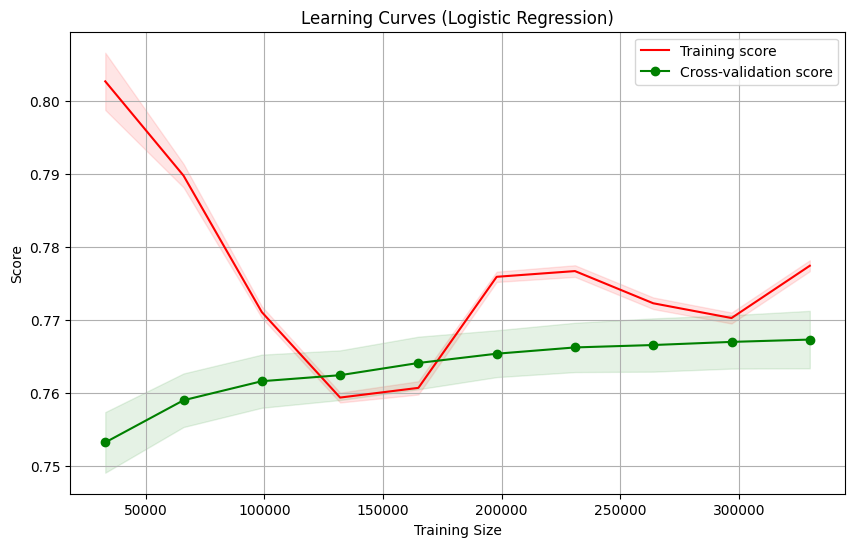

In [28]:
# Plotting performance of the best model
train_sizes, train_scores, test_scores = learning_curve(
    best_lr,
    X_train,
    y_train,
    groups=train_groups,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=group_cv,
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.title('Learning Curves (Logistic Regression)')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()


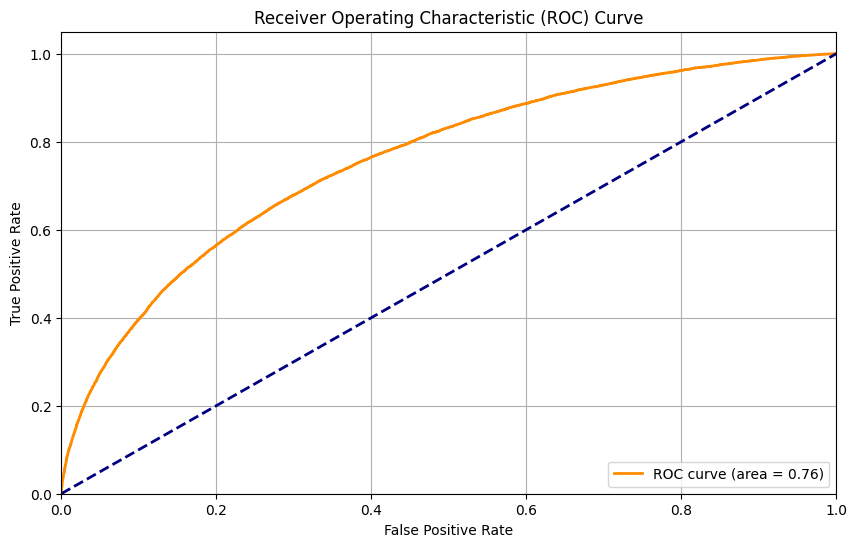

In [29]:
y_prob = best_lr.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)

# Calculate the AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Model Limitations

In [30]:
majority_baseline_accuracy = (y_test == False).mean()
lr_report = classification_report(y_test, y_pred_best_lr, output_dict=True, zero_division=0)
spoiler_key = str(True)

test_accuracy = accuracy_score(y_test, y_pred_best_lr)
spoiler_precision = lr_report[spoiler_key]['precision']
spoiler_recall = lr_report[spoiler_key]['recall']
spoiler_f1 = lr_report[spoiler_key]['f1-score']

cm_lr = confusion_matrix(y_test, y_pred_best_lr, labels=[False, True])
tn, fp, fn, tp = cm_lr.ravel()

false_negative_mask = (y_test.reset_index(drop=True) == True) & (~pd.Series(y_pred_best_lr).astype(bool))
false_negatives = test_df.loc[false_negative_mask, ['movie_id', 'review_summary', 'review_text']].copy()
false_negatives['spoiler_probability'] = y_prob[false_negative_mask.to_numpy()]
false_negatives = false_negatives.sort_values('spoiler_probability').head(5)

print(f'Majority-class baseline accuracy (always predict non-spoiler): {majority_baseline_accuracy:.3f}')
print(f'Logistic Regression test accuracy: {test_accuracy:.3f}')
print(f'Spoiler precision: {spoiler_precision:.3f}')
print(f'Spoiler recall: {spoiler_recall:.3f}')
print(f'Spoiler F1-score: {spoiler_f1:.3f}')


Majority-class baseline accuracy (always predict non-spoiler): 0.750
Logistic Regression test accuracy: 0.781
Spoiler precision: 0.634
Spoiler recall: 0.290
Spoiler F1-score: 0.398


### Examples of missed spoiler reviews (false negatives)

In [31]:
with pd.option_context('display.max_colwidth', 150):
    display(false_negatives[['spoiler_probability', 'review_text']])
    

,spoiler_probability,review_text
26439,0.016008,"wow, i did not see that coming. unfortunately , it's rare to see this amount of dedication and talent in contemporary mainstream American cinema t..."
72070,0.019712,"Made in 1997 from the comic book series created by Todd McFarlane, Spawn is an unforgettable hell of a cool comic book flick! The artwork and the ..."
1211,0.020247,"Cidade de Deus (City of God) based on the ghettos of Rio de Janeiro, Brazil is a GEM of Brazilian cinema. It is right at the top of my top 10 movi..."
66588,0.022138,Carlito's way is Scarface's older brother...it's a movie with a similar theme and with the same director and lead actor. I believe Carlito's way t...
1233,0.023878,"Based on a true story of drugs and corruption on Brazil, this movie is amazing, so as photograph as acting and text. Is really important (and sad ..."


### Top spoiler cues

In [32]:
feature_names = np.asarray(vectorizer.get_feature_names_out())
coefficients = best_lr.coef_[0]

pos_idx = np.argsort(coefficients)[-10:][::-1]
neg_idx = np.argsort(coefficients)[:10]

top_spoiler_cues = pd.DataFrame({
    'feature': feature_names[pos_idx],
    'weight': coefficients[pos_idx],
})

top_non_spoiler_cues = pd.DataFrame({
    'feature': feature_names[neg_idx],
    'weight': coefficients[neg_idx],
})

print('Top spoiler cues')
display(top_spoiler_cues)
print('Top non-spoiler cues')
display(top_non_spoiler_cues)


Top spoiler cues


,feature,weight
0,spoiler,13.925898
1,dy,4.633210
2,kill,4.294036
3,alert,4.118695
4,end,3.941824
5,die,3.690331
6,death,3.106979
7,rape,2.859781
8,sacrifice,2.684845
9,stab,2.468339


Top non-spoiler cues


,feature,weight
0,cliche,-3.566489
1,brazil,-3.332166
2,writerdirector,-1.902402
3,filmmaking,-1.894757
4,ambitious,-1.886910
5,youll,-1.743692
6,banderas,-1.711603
7,spoil,-1.682400
8,brosnan,-1.676438
9,wellwritten,-1.637741


## Data Limitations

  A second limitation comes from data quality rather than the model alone.
  The IMDb spoiler label is user-provided, so it is not perfectly reliable.
  The dataset paper reports that among reviews containing the word `spoiler`, more than 25% were still not annotated as
  spoiler on IMDb.
  
  This suggests some spoiler reviews may be mislabeled as non-spoiler, which introduces label noise.
  As a result, the model may learn inconsistent patterns, and the measured recall for spoiler detection may
  underestimate the true difficulty of the task.